# Balanced OMAMA Dataset Quick Analysis

This notebook gives us a first look at the balanced mammogram set sitting in scratch.
It stays read-only: we only load images/metadata, look at basic stats, and preview how windowing might behave.


In [1]:
from pathlib import Path
import random
import json

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


## Imports

Keep dependencies lightweight—just NumPy/Matplotlib and a few helpers for file handling.


In [2]:
# Point everything at the balanced scratch dataset
SCRATCH_ROOT = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma")
DATASET_DIR = SCRATCH_ROOT / "test_balanced"
IMAGE_DIR = DATASET_DIR / "images"
META_DIR = DATASET_DIR / "metadata"

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Couldn't find images in {IMAGE_DIR}")
if not META_DIR.exists():
    raise FileNotFoundError(f"Couldn't find metadata in {META_DIR}")

print("Images:", IMAGE_DIR)
print("Metadata:", META_DIR)


Images: /hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/test_balanced/images
Metadata: /hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/test_balanced/metadata


## Locate the dataset

Point the notebook at the balanced copy you prepared in scratch.
Raise an error early if something’s missing so we don’t chase silent bugs later.


In [3]:
# Quick headcount so we know what we're working with
npz_files = sorted(IMAGE_DIR.glob("*.npz"))
json_files = sorted(META_DIR.glob("*.json"))

print(f"Image files: {len(npz_files):,}")
print(f"Metadata files: {len(json_files):,}")

if not npz_files:
    raise RuntimeError("No .npz files found. Check that the dataset is in the expected place.")

print("Sample filenames:")
for path in random.sample(npz_files, min(5, len(npz_files))):
    print(" -", path.name)


Image files: 11,606
Metadata files: 11,606
Sample filenames:
 - 214645508036748310958965483462826140525.npz
 - 183544828951138285984749999535366167191.npz
 - 11468658080666883059938476761463155847.npz
 - 143872633219139994468422279279803471931.npz
 - 246589715052389749182724002180653555489.npz


## Quick inventory

Count how many `.npz` images and metadata JSONs we have, and glance at a few file names to make sure the paths look right.


In [4]:
def load_npz(path: Path) -> np.ndarray:
    with np.load(path, mmap_mode="r") as data:
        arr = data["data"].astype(np.float32)
    return arr


def load_meta(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def fetch_pair(idx: int) -> tuple[Path, Path]:
    img_path = npz_files[idx]
    meta_path = META_DIR / f"{img_path.stem}.json"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata for {img_path.name}")
    return img_path, meta_path


## Helper functions

A couple of small utilities to load the `.npz` pixel data, read metadata, and fetch matching pairs by index.


In [5]:
# Take a look at one random sample
idx = random.randrange(len(npz_files))
img_path, meta_path = fetch_pair(idx)
print(f"Index: {idx}")
print("Image file:", img_path.name)
print("Metadata file:", meta_path.name)

image = load_npz(img_path)
meta = load_meta(meta_path)

print("Shape:", image.shape)
print("dtype:", image.dtype)
print("Value range:", float(image.min()), "→", float(image.max()))
print("Mean ± std:", float(image.mean()), "±", float(image.std()))
print("Metadata keys:", list(meta.keys()))
display(meta)


Index: 8350
Image file: 254918483888834581169625822700254905099.npz
Metadata file: 254918483888834581169625822700254905099.json
Shape: (512, 512)
dtype: float32
Value range: 0.0 → 4094.0
Mean ± std: 1018.0576171875 ± 1073.7926025390625
Metadata keys: ['PatientID', 'View', 'WindowCenter', 'WindowWidth', 'WindowCenterWidthExplanation', 'ImagerPixelSpacing', 'ImageLaterality', 'coords', 'score', 'label']


{'PatientID': 'DHBAUH5X3B8Q',
 'View': 'medio-lateral oblique',
 'WindowCenter': [2569.0, 2599.0, 2527.0],
 'WindowWidth': [900.0, 750.0, 1050.0],
 'WindowCenterWidthExplanation': ['NORMAL', 'HARDER', 'SOFTER'],
 'ImagerPixelSpacing': [0.1, 0.1],
 'ImageLaterality': 'L',
 'coords': [95, 303, 156, 363],
 'score': 0.04337654635310173,
 'label': 'NonCancer'}

## Inspect one random case

Pull a sample image + metadata, print the basics (shape, ranges, stats), and display the metadata dictionary for context.


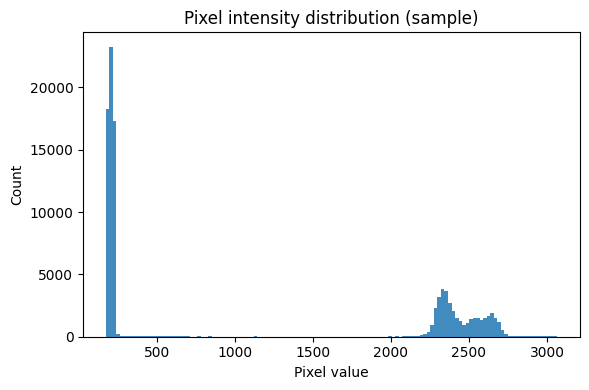

In [6]:
# Histogram of pixel intensities (subset for speed)
flat = image.ravel()
subset = flat if flat.size <= 100_000 else flat[:100_000]
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(subset, bins=128, color="tab:blue", alpha=0.85)
ax.set_title("Pixel intensity distribution (sample)")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Pixel histogram

Look at the intensity spread for a quick feel of contrast. We sample up to 100k pixels just to keep plotting fast.


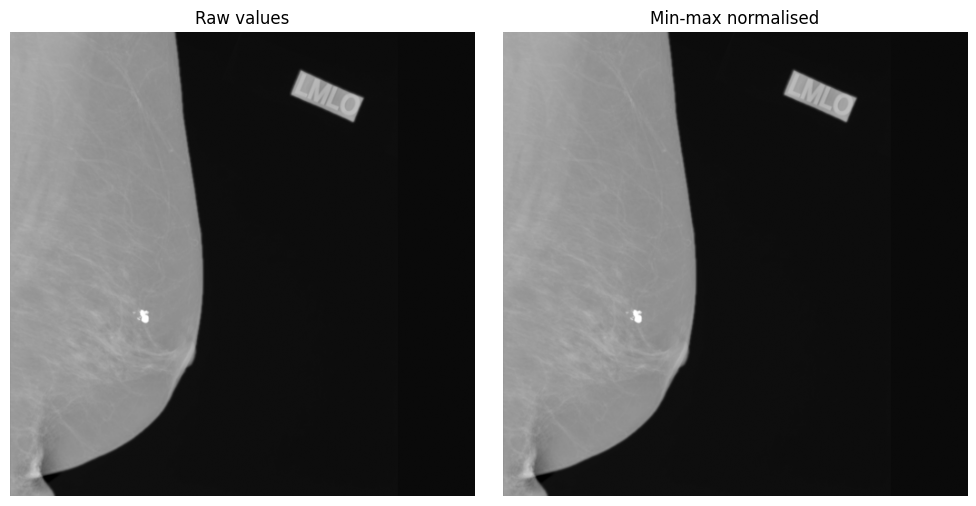

In [7]:
# Quick side-by-side view: raw vs simple min-max
norm = (image - image.min()) / max(1e-6, image.max() - image.min())
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Raw values")
axes[0].axis("off")
axes[1].imshow(norm, cmap="gray")
axes[1].set_title("Min-max normalised")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Visual check: raw vs min-max

Display the raw array next to a simple min–max normalised version to see how it looks without any fancy processing.


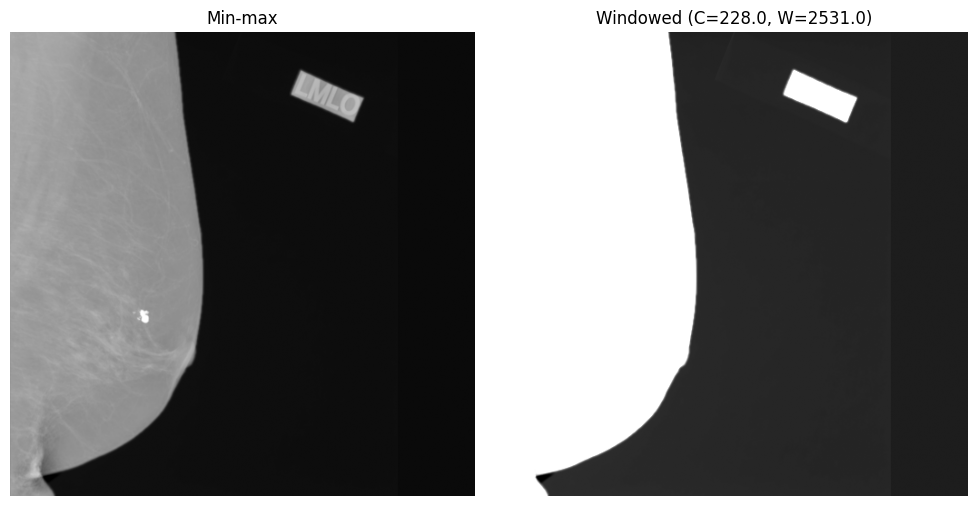

In [8]:
def window_level(img: np.ndarray, center: float, width: float) -> np.ndarray:
    lower = center - width / 2
    upper = center + width / 2
    clipped = np.clip(img, lower, upper)
    return (clipped - lower) / max(1e-6, upper - lower)

# One possible window: median centre, 1st–99th percentile width
centre_guess = float(np.median(image))
width_guess = float(np.percentile(image, 99) - np.percentile(image, 1))
windowed = window_level(image, centre_guess, width_guess)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(norm, cmap="gray")
axes[0].set_title("Min-max")
axes[0].axis("off")
axes[1].imshow(windowed, cmap="gray")
axes[1].set_title(f"Windowed (C={centre_guess:.1f}, W={width_guess:.1f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Window-level preview (optional)

Try a simple centre/width guess so you can judge whether windowing adds useful contrast before we bake it into preprocessing.
